## Figure — spread ADI/MPWR : retour à la moyenne et demi-vie

Spread, sa moyenne de long terme, et depuis un pic la décroissance théorique de l'Ornstein–Uhlenbeck (réduction de moitié de l'écart en une demi-vie $\approx 43$ jours).

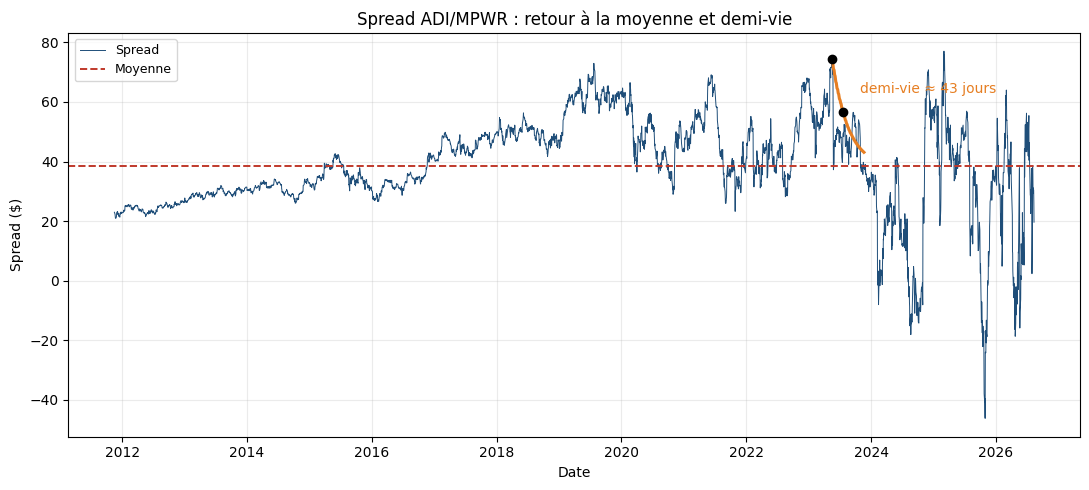

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.dates as mdates

adj = pd.read_csv("../data/sp500full_adj_close.csv", index_col=0, parse_dates=True)

beta = 0.256
S  = (adj["ADI"] - beta * adj["MPWR"]).dropna()
mu = S.mean()
H  = 43                      # demi-vie (jours de bourse)
kappa = np.log(2) / H

# pic representatif + decroissance theorique de l'O-U depuis ce pic
n = len(S)
seg = (S.iloc[int(.2*n):int(.8*n)] - mu).abs()
i0 = seg.idxmax(); p0 = S.index.get_loc(i0); S0 = S.loc[i0]; dev0 = S0 - mu
idx  = S.index[p0:p0+130]; t = np.arange(len(idx))
theo = mu + dev0 * np.exp(-kappa * t)
iH   = S.index[p0+H]; theoH = mu + dev0 * np.exp(-kappa * H)   # moitie de l'ecart

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(S.index, S, lw=.7, color="#1f4e79", label="Spread")
ax.axhline(mu, color="#c0392b", lw=1.4, ls="--", label="Moyenne")
ax.plot(idx, theo, color="#e67e22", lw=2.2)          # decroissance theorique (sans label)

ax.plot([i0, iH], [S0, theoH], "o", color="k", ms=6, zorder=5)   # pic et point a +43 j
ax.annotate("demi-vie ≈ 43 jours", xy=(iH, theoH), xytext=(12, 14),
            textcoords="offset points", fontsize=10, color="#e67e22")

ax.set_ylabel("Spread ($)"); ax.set_xlabel("Date")
ax.set_title("Spread ADI/MPWR : retour à la moyenne et demi-vie")
ax.legend(loc="upper left", fontsize=9); ax.grid(alpha=.25)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.savefig("fig_spread_halflife.png", dpi=150)
plt.show()